In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

A **deeper network** — one with more layers — has more **representational power**. In theory, it can:

- Learn more **complex, non-linear patterns**,
- Capture **hierarchical features** (e.g., edges → textures → objects),
- Offer **better generalization** on large, rich datasets like CIFAR-10.

But deeper isn’t always better — deeper models are **harder to train**.

They often suffer from:

- ⚠️ **Vanishing gradients**: updates become too small to be useful.
- ⚠️ **Exploding gradients**: updates become too large and unstable.
- ⚠️ **Unstable training dynamics**: losses oscillate or fail to converge.


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

train_val_data = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_data      = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

100%|██████████| 170M/170M [27:21<00:00, 104kB/s]


In [3]:
train_size = int(0.9 * len(train_val_data))   # 45,000
val_size   = len(train_val_data) - train_size # 5,000
train_data, val_data = random_split(train_val_data, [train_size, val_size])

In [4]:
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)


class_names = train_val_data.classes

print(f" Train batches: {len(train_loader)}")
print(f" Validation batches: {len(val_loader)}")
print(f" Test batches: {len(test_loader)}")
print(f" Input dimension: {next(iter(train_loader))[0].shape[1]}")
print(f" Number of classes: {len(class_names)}")


 Train batches: 704
 Validation batches: 79
 Test batches: 157
 Input dimension: 3072
 Number of classes: 10


In [5]:
# Verify CIFAR-10 dataset and input dimensions


CT_images_batch, CT_labels_batch = next(iter(train_loader))

CT_Number_of_classes = class_names

# Print batch details
print("CT_Train batch size:", CT_images_batch.shape[0])
print("CT_Input dimension:", CT_images_batch.shape[1])
print("CT_Number of classes:", len(CT_Number_of_classes))

CT_Train batch size: 64
CT_Input dimension: 3072
CT_Number of classes: 10


To test the limits of basic training, we’ll now define a **deeper MLP** — one with **5 hidden layers** — but **without using any advanced tricks** like:

- Xavier or He initialization
- Batch Normalization
- Dropout
- Skip connections
- Better optimizers

This helps us build a **baseline** and understand **why deeper networks struggle without care**.

>🧱 Model Architecture

We’ll use:

- **Input layer**: 3072 units (32×32×3)
- **5 hidden layers**: each with 128 units + ReLU
- **Output layer**: 10 units (CIFAR-10 classes)


In [6]:
# Define deeper MLP
class DeepMLP(nn.Module):
    def __init__(self, input_dim=3072, hidden_dim=128, output_dim=10):
        super(DeepMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)  # Final output layer
        )

    def forward(self, x):
        return self.network(x)

# Instantiate the model
relu_deep_mlp = DeepMLP()
print(relu_deep_mlp)

DeepMLP(
  (network): Sequential(
    (0): Linear(in_features=3072, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [7]:
CT_model_deep = DeepMLP()

print(CT_model_deep)

CT_total_params = sum(p.numel() for p in CT_model_deep.parameters())
print("CT_Total trainable parameters:", CT_total_params)

DeepMLP(
  (network): Sequential(
    (0): Linear(in_features=3072, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)
CT_Total trainable parameters: 460682


In [8]:
def train_deep_model(model, train_loader, val_loader, num_epochs=15, lr=0.001, epochs = 10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_loss_list, val_loss_list = [], []
    train_acc_list, val_acc_list = [], []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss /= total
        train_accuracy = correct / total
        train_loss_list.append(train_loss)
        train_acc_list.append(train_accuracy)

        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= val_total
        val_accuracy = val_correct / val_total
        val_loss_list.append(val_loss)
        val_acc_list.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {train_loss:.4f}, Acc: {train_accuracy:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_accuracy:.4f}")

    return train_loss_list, val_loss_list, train_acc_list, val_acc_list


In [ ]:

relu_train_losses, relu_val_losses, relu_train_accuracies, relu_val_accuracies = train_deep_model(
    relu_deep_mlp, train_loader, val_loader, epochs=15
)

Epoch [1/15] - Train Loss: 1.9491, Acc: 0.2715 | Val Loss: 1.8197, Acc: 0.3378
Epoch [2/15] - Train Loss: 1.7516, Acc: 0.3625 | Val Loss: 1.7705, Acc: 0.3582
Epoch [3/15] - Train Loss: 1.6714, Acc: 0.3970 | Val Loss: 1.7191, Acc: 0.3950
Epoch [4/15] - Train Loss: 1.6130, Acc: 0.4188 | Val Loss: 1.6486, Acc: 0.4052
Epoch [5/15] - Train Loss: 1.5638, Acc: 0.4356 | Val Loss: 1.5702, Acc: 0.4340
Epoch [6/15] - Train Loss: 1.5299, Acc: 0.4481 | Val Loss: 1.5904, Acc: 0.4350


In [ ]:
# Plot loss and accuracy
plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(relu_train_losses, label='Train Loss')
plt.plot(relu_val_losses, label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(relu_train_accuracies, label='Train Acc')
plt.plot(relu_val_accuracies, label='Val Acc')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

Common Problems in Deep Networks


| Problem             | Symptom in Curves                | Possible Cause       |
| ------------------- | -------------------------------- | -------------------- |
| Vanishing Gradients | Loss stays flat, low accuracy    | Gradients too small  |
| Exploding Gradients | Spikes in loss, erratic accuracy | Gradients too large  |
| Poor Initialization | Any of the above                 | Random weight scales |

---

# How Activation Functions affect Training

In deep neural networks, the choice of **activation function** plays a major role in:

- How well the model learns complex patterns (non-linearity),
- How **gradients flow** during backpropagation,
- Whether training is **stable** or suffers from **vanishing** or **exploding** gradients.

So far, we’ve been using **ReLU**, which is the most common activation. But how does it compare to alternatives like **Tanh**?

Let’s investigate by comparing training behavior with the **same network architecture**, but a different activation function.

> **ReLU vs. Tanh — A Quick Recap**

**ReLU (Rectified Linear Unit)**: ReLU is simple: it outputs the input if it’s positive, and 0 otherwise. This means neurons are "active" only when they see positive signals. Think of a ReLU neuron like a light switch that turns on only for positive values — simple and efficient.

Why ReLU works well:
- Its gradient is either **0 or 1**, so gradients don’t shrink as easily.
- It **avoids saturation** — there’s no upper cap like Tanh or Sigmoid.
- **Training is usually faster** and more stable with ReLU.

However, some neurons might "die" if they only receive negative inputs forever — these never activate and stop learning. This is called the **Dying ReLU problem**.

**Tanh (Hyperbolic Tangent)**: Tanh squashes inputs to the range between **-1 and 1**. It’s **symmetric around zero**, which can help early in training. Think of Tanh as a soft squashing spring — it compresses all signals to stay within a narrow zone.

But here's the issue:
- In deep networks, after several layers, signals can get **squashed too much**.
- This causes **gradients to shrink** as they move backward — a problem known as the **vanishing gradient**.
- The network struggles to learn because the updates become too tiny.

In summary, ReLU is like a sharp-edged filter: fast, sparse, and generally stable — but watch for inactive neurons. Tanh is smooth and bounded — better for shallow nets, but not great for deep ones due to vanishing gradients.

>**Our Experiment: Same Network, Different Activations**

We’ve already trained our **5-hidden-layer MLP with ReLU** in the previous section.

Let’s now define an **identical architecture** but replace `ReLU` with `Tanh`.

We’ll train it under the same conditions (optimizer, epochs, batch size) and compare **loss and accuracy curves**.

In [ ]:
class DeepMLP_Tanh(nn.Module):
    def __init__(self, input_dim=3072, hidden_dim=128, output_dim=10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.network(x)


# Instantiate the model
tanh_deep_mlp = DeepMLP_Tanh()
print(tanh_deep_mlp)

In [12]:
tanh_train_losses, tanh_val_losses, tanh_train_accuracies, tanh_val_accuracies = train_deep_model(
    tanh_deep_mlp, train_loader, val_loader, epochs=15
)

Epoch [1/15] - Train Loss: 1.9993, Acc: 0.2523 | Val Loss: 1.8878, Acc: 0.3132
Epoch [2/15] - Train Loss: 1.9004, Acc: 0.3027 | Val Loss: 1.9329, Acc: 0.2968
Epoch [3/15] - Train Loss: 1.8668, Acc: 0.3210 | Val Loss: 1.8669, Acc: 0.3278
Epoch [4/15] - Train Loss: 1.8368, Acc: 0.3350 | Val Loss: 1.8364, Acc: 0.3406
Epoch [5/15] - Train Loss: 1.8133, Acc: 0.3454 | Val Loss: 1.8004, Acc: 0.3456
Epoch [6/15] - Train Loss: 1.8024, Acc: 0.3490 | Val Loss: 1.8363, Acc: 0.3420
Epoch [7/15] - Train Loss: 1.7891, Acc: 0.3538 | Val Loss: 1.7993, Acc: 0.3428
Epoch [8/15] - Train Loss: 1.7699, Acc: 0.3670 | Val Loss: 1.7792, Acc: 0.3602
Epoch [9/15] - Train Loss: 1.7595, Acc: 0.3649 | Val Loss: 1.7566, Acc: 0.3726
Epoch [10/15] - Train Loss: 1.7443, Acc: 0.3751 | Val Loss: 1.8531, Acc: 0.3336
Epoch [11/15] - Train Loss: 1.7370, Acc: 0.3774 | Val Loss: 1.7842, Acc: 0.3458
Epoch [12/15] - Train Loss: 1.7331, Acc: 0.3782 | Val Loss: 1.7480, Acc: 0.3582
Epoch [13/15] - Train Loss: 1.7316, Acc: 0.3776 |

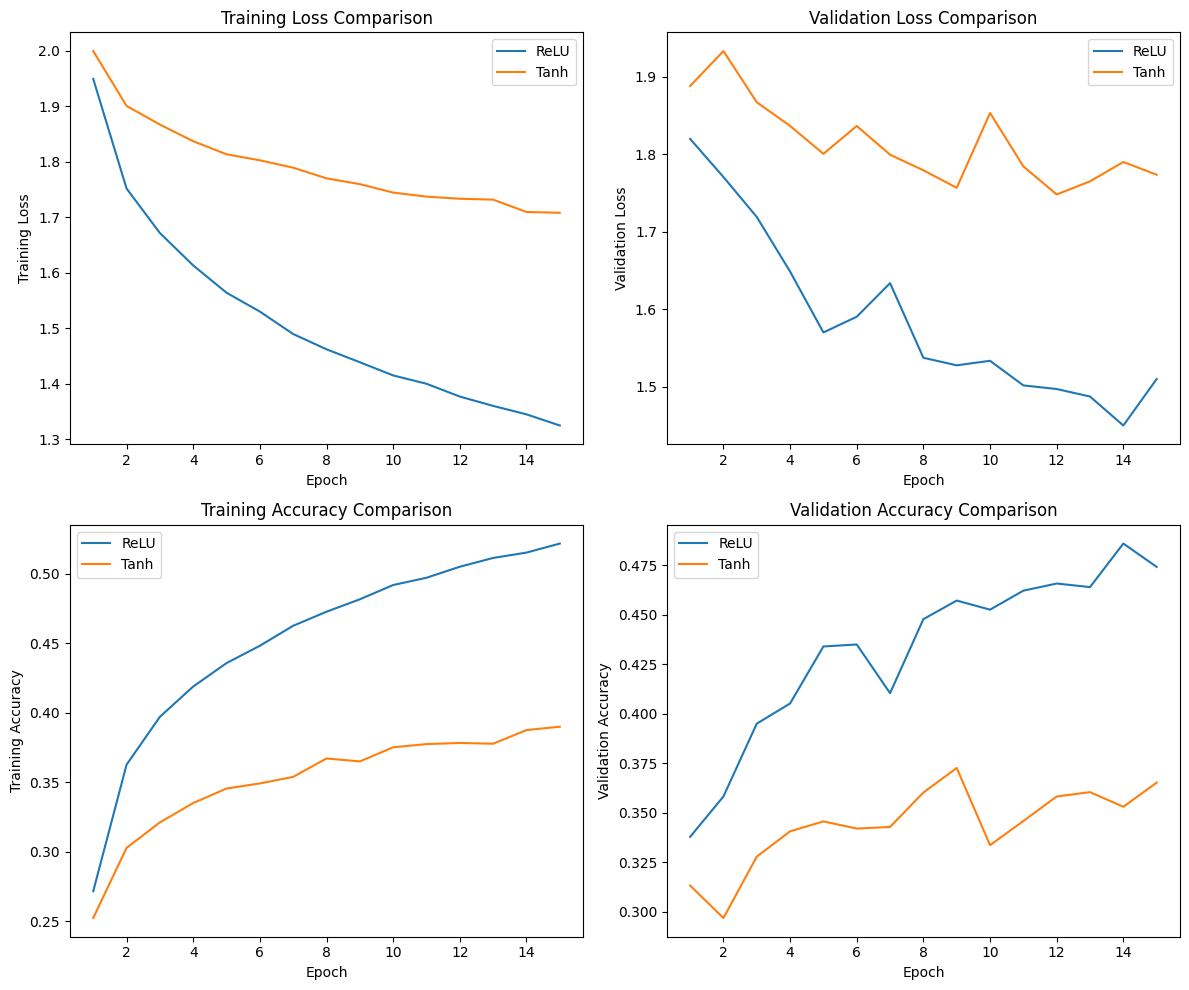

In [13]:
epochs = range(1, len(tanh_train_losses) + 1)

plt.figure(figsize=(12, 10))

# Train Loss
plt.subplot(2, 2, 1)
plt.plot(epochs, relu_train_losses, label="ReLU")  # from Section 3
plt.plot(epochs, tanh_train_losses, label="Tanh")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()

# Validation Loss
plt.subplot(2, 2, 2)
plt.plot(epochs, relu_val_losses, label="ReLU")  # from Section 3
plt.plot(epochs, tanh_val_losses, label="Tanh")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()

# Train Accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, relu_train_accuracies, label="ReLU")  # from Section 3
plt.plot(epochs, tanh_train_accuracies, label="Tanh")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()

# Validation Accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, relu_val_accuracies, label="ReLU")  # from Section 3
plt.plot(epochs, tanh_val_accuracies, label="Tanh")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.tight_layout()
plt.show()

> Insights

- **ReLU** converges faster and reaches **higher accuracy** than Tanh.
- **Tanh** suffers from **slower learning** and **lower performance**, especially in deep networks.
- This is due to **vanishing gradients** caused by Tanh's saturation behavior (squashing values to -1 and 1).

# **How Do Gradients Behave in Deep Networks**

One major culprit is poor gradient flow. Let's understand this through intuition and code.
 What Is Gradient Flow?

When we backpropagate errors during training, gradients flow from the output layer to earlier layers.

If gradients are:

- Very small (close to 0): early layers learn very little.
    → This is called the vanishing gradient problem.

- Very large: weights change erratically, leading to instability.
    → This is called the exploding gradient problem.

Both issues make training slow, unstable, or completely ineffective.

In [14]:
def track_gradient_norms(model, train_loader, num_epochs=10, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    gradient_history = []

    for epoch in range(num_epochs):
        model.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            # Record L2 norm of gradients for each layer
            grad_norms = []
            for param in model.parameters():
                if param.grad is not None:
                    grad_norm = param.grad.detach().norm(2).item()
                    grad_norms.append(grad_norm)
            gradient_history.append(grad_norms)

            optimizer.step()
            break  # Only one batch per epoch for gradient tracking (faster)

        print(f"Epoch {epoch+1}/{num_epochs}  Gradient norms tracked.")

    return gradient_history


In [15]:
def plot_gradient_norms(gradient_history):

    grad_array = np.array(gradient_history)  # shape: (epochs, num_params)
    plt.figure(figsize=(10, 6))

    for i in range(grad_array.shape[1]):
        plt.plot(grad_array[:, i], label=f"Layer {i+1}")

    plt.title("Gradient Norms Across Layers (Over Epochs)")
    plt.xlabel("Epochs")
    plt.ylabel("Gradient L2 Norm")
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()


In [16]:
def plot_gradient_norms(gradient_history):
    import numpy as np
    import matplotlib.pyplot as plt

    grad_array = np.array(gradient_history)  # shape: (epochs, num_params)
    plt.figure(figsize=(10, 6))

    for i in range(grad_array.shape[1]):
        plt.plot(grad_array[:, i], label=f"Layer {i+1}")

    plt.title("Gradient Norms Across Layers (Over Epochs)")
    plt.xlabel("Epochs")
    plt.ylabel("Gradient L2 Norm")
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()


In [17]:
def track_gradient_norms(model, train_loader, num_epochs=10, lr=0.001):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    gradient_history = []

    for epoch in range(num_epochs):
        model.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            # Record only weight gradients (not biases)
            grad_norms = []
            for name, param in model.named_parameters():
                if "weight" in name and param.grad is not None:
                    grad_norm = param.grad.detach().norm(2).item()
                    grad_norms.append(grad_norm)

            gradient_history.append(grad_norms)
            break  # One batch per epoch

        print(f"Epoch {epoch+1}/{num_epochs}  Tracked {len(grad_norms)} weight gradients.")

    return gradient_history

In [18]:
def plot_gradient_norms(gradient_history):
    grad_array = np.array(gradient_history)
    plt.figure(figsize=(10, 6))

    line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 5))]

    for i in range(grad_array.shape[1]):
        label = f"Layer {i+1}: Linear"
        plt.plot(grad_array[:, i], linestyle=line_styles[i % len(line_styles)], label=label)

    plt.title("Weight Gradient Norms Across Layers (Over Epochs)")
    plt.xlabel("Epoch")
    plt.ylabel("L2 Norm of Gradient")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



Epoch 1/15  Tracked 6 weight gradients.
Epoch 2/15  Tracked 6 weight gradients.
Epoch 3/15  Tracked 6 weight gradients.
Epoch 4/15  Tracked 6 weight gradients.
Epoch 5/15  Tracked 6 weight gradients.
Epoch 6/15  Tracked 6 weight gradients.
Epoch 7/15  Tracked 6 weight gradients.
Epoch 8/15  Tracked 6 weight gradients.
Epoch 9/15  Tracked 6 weight gradients.
Epoch 10/15  Tracked 6 weight gradients.
Epoch 11/15  Tracked 6 weight gradients.
Epoch 12/15  Tracked 6 weight gradients.
Epoch 13/15  Tracked 6 weight gradients.
Epoch 14/15  Tracked 6 weight gradients.
Epoch 15/15  Tracked 6 weight gradients.


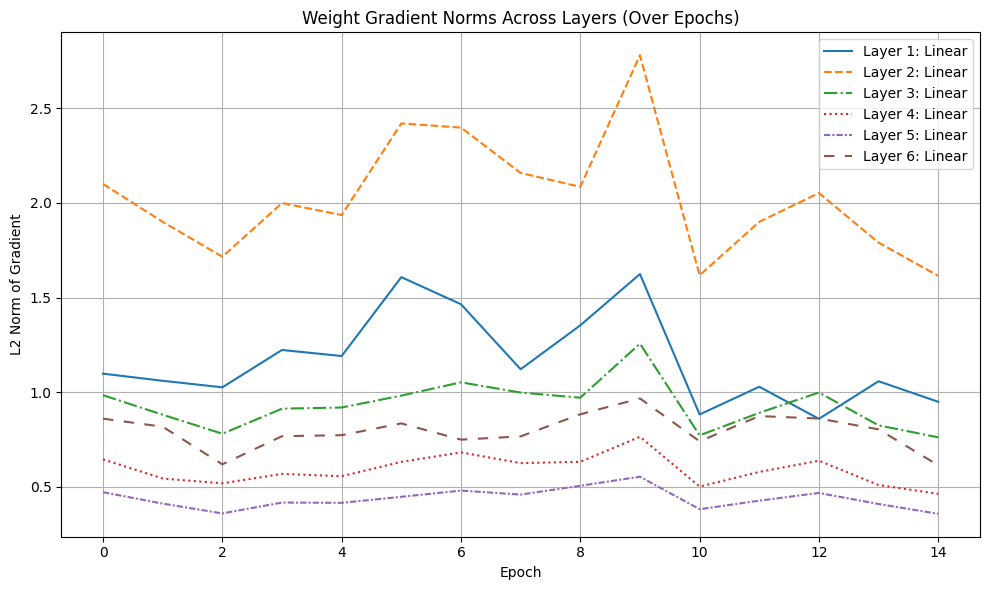

In [19]:
gradient_history = track_gradient_norms(relu_deep_mlp, train_loader, num_epochs=15)
plot_gradient_norms(gradient_history)

# What Do the Curves Tell Us?

- Layers with **higher gradient norms** are updating more — this means their weights are receiving stronger learning signals.
- Layers with **very small or flat gradients** may be experiencing the **vanishing gradient problem**.
- If a layer’s gradients become **too large or spiky**, it may indicate **exploding gradients**, leading to instability.

> For example:
- If **earlier layers** (closer to the input) show tiny gradients, it means learning is not effectively reaching them.
- If the **last layer** dominates the update signals, the network may rely too much on the last transformation, limiting learning depth.

> Why This Matters

- Deep networks **rely on good gradient flow** to learn across all layers.
- Poor flow = some layers don't learn much = shallow effective capacity despite deep architecture.
- We’ll soon explore **weight initialization strategies** (like Xavier and He) designed to **preserve gradient magnitudes**, allowing deeper layers to learn effectively.

---

In [21]:
CT_model_grad = DeepMLP()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CT_model_grad.to(device)

# Loss and optimizer
CT_criterion_grad = nn.CrossEntropyLoss()
CT_optimizer_grad = optim.Adam(CT_model_grad.parameters(), lr=0.001)

# Get one batch
CT_images_grad, CT_labels_grad = next(iter(train_loader))
CT_images_grad, CT_labels_grad = CT_images_grad.to(device), CT_labels_grad.to(device)

# Forward pass
CT_outputs_grad = CT_model_grad(CT_images_grad)
CT_loss_grad = CT_criterion_grad(CT_outputs_grad, CT_labels_grad)

# Backward pass
CT_optimizer_grad.zero_grad()
CT_loss_grad.backward()

# Record L2 norms for weights
CT_grad_norms = []
for CT_name, CT_param in CT_model_grad.named_parameters():
    if "weight" in CT_name and CT_param.grad is not None:
        CT_grad_norms.append(CT_param.grad.detach().norm(2).item())

print("CT_Gradient Norms (first batch):", CT_grad_norms)

CT_Gradient Norms (first batch): [0.039551351219415665, 0.007694928906857967, 0.007493381388485432, 0.009464329108595848, 0.022705931216478348, 0.06057541072368622]


# Weight Initialization

In the previous section, we saw that training our deep MLP showed **uneven gradient flow** — some layers received strong updates, others barely learned at all. This wasn't a bug in our optimizer or data — the real culprit lies in **how the model was initialized**.

Let’s unpack this.

> 🧠 **The Problem with Default Initialization in PyTorch**

When we define a model using `nn.Linear` layers in PyTorch, the weights are **automatically initialized** using a method called:

```python
nn.init.kaiming_uniform_  # a.k.a. He Uniform
```

This is **a variant of He Initialization**, designed for **ReLU-based activations**, and is a solid choice *if* we use ReLU.

But here's the catch:

> 🔎 PyTorch applies this **regardless of the activation** we plan to use later.

This means:
- Even if we use **Tanh** (or **Sigmoid**), the layers still get initialized with **He Uniform**.
- But He initialization is **not well-suited** for these activations — and this mismatch leads to **poor learning** in deep networks.

>**Why Mismatched Initialization Breaks Training**

Let’s break down what happens with poor initialization choices:

**❌ Too Small Weights?**
- Activations shrink layer by layer.
- Gradients vanish during backpropagation.
- → **Vanishing gradients**: early layers stop learning.

**❌ Too Large Weights?**
- Activations explode as they pass through layers.
- Gradients grow uncontrollably.
- → **Exploding gradients**: unstable or diverging training.

These issues break the learning signal. Some layers dominate; others fall silent.

>🔍 What’s Actually Going Wrong?

Let’s say we start with an input vector **x** and pass it through many linear layers:

$$
\text{Layer 1: } x_1 = W_1 x \\
\text{Layer 2: } x_2 = W_2 x_1 \\
\text{... and so on}
$$

If the **variance** of activations or gradients grows or shrinks across layers, learning becomes unstable.  
We want each layer to **preserve the scale** of both:
- **Forward activations**
- **Backward gradients**

That’s where **smart initialization strategies** come in.

>**✅ Xavier and He: Designed to Preserve Variance**

Researchers proposed two initialization methods tailored to specific activation functions:

| Init Method | Designed For | Goal |
|-------------|--------------|------|
| **Xavier (Glorot)** | Tanh / Sigmoid | Preserve both forward and backward variance |
| **He (Kaiming)**    | ReLU / Leaky ReLU | Compensate for zeroed-out negative values |


</br>

>🔄 Think of Initialization Like Pouring Water Through Pipes

Let’s use a plumbing analogy:

- Each layer is a **pipe**.
- If a pipe is **too narrow** (small weights) → water trickles → **vanishing gradients**.
- If it’s **too wide** (large weights) → it floods → **exploding gradients**.
- A good initialization **sizes each pipe just right**, based on how many inputs/outputs it connects.

>**📌Xavier (Glorot) Initialization**

- Designed for symmetric activations like **Tanh** and **Sigmoid**.
- Assumes we want to preserve **equal variance** in both directions (forward & backward).
- Balances the scale by averaging the number of inputs and outputs.

**Formula (Uniform distribution):**

$$
W \sim \mathcal{U}\left[-\frac{\sqrt{6}}{\sqrt{n_{in} + n_{out}}}, \frac{\sqrt{6}}{\sqrt{n_{in} + n_{out}}}\right]
$$

💡 Think of it as: “Let’s keep the flow steady in both directions — no shrinking, no growing.”

🧪 In this notebook, we use **Tanh** to demonstrate this. But you can also try **Sigmoid** — it benefits from Xavier for the same reason.

👉 **If you want to try Sigmoid**, change the activation in your model from `Tanh()` to `Sigmoid()` — and use Xavier initialization just the same.

>**📌He (Kaiming) Initialization**

- Built for **ReLU-based** activations.
- ReLU discards all negative inputs — so signal is lost.
- He initialization compensates by increasing weight variance slightly.

> 🧮 **He Initialization: Two Variants**

There are **two forms** of He initialization depending on the distribution used:

1. **He Normal**

Weights are drawn from a **normal distribution**:

$$
W \sim \mathcal{N}\left(0, \frac{2}{n_{in}}\right)
$$

This is what we typically refer to when we say "He Initialization" in most theoretical discussions.

2. **He Uniform**

Weights are drawn from a **uniform distribution** over the range:

$$
W \sim \mathcal{U}\left[-\sqrt{\frac{6}{n_{in}}}, \sqrt{\frac{6}{n_{in}}} \right]
$$

This variant is used by **default in PyTorch** for `nn.Linear` layers when using ReLU.

> ✅ If we write:
```python
nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
```
PyTorch will automatically apply He Uniform tailored for ReLU.

> 🎯 In summary:

| Variant        | Distribution Type | Formula | When to Use         |
|----------------|-------------------|---------|----------------------|
| **He Normal**  | Normal            | 𝑁(0, 2/𝑛ᵢₙ) | When you want to explore theoretical or experimental variations |
| **He Uniform** | Uniform           | 𝕌[−√(6/𝑛ᵢₙ), √(6/𝑛ᵢₙ)] | PyTorch's default for ReLU activations |

**As we said, if we don’t explicitly set initialization, PyTorch by default uses He Uniform.**

Which means:
- If you're using **ReLU**, this default is **okay** (though not optimal).
- If you're using **Tanh** or **Sigmoid**, this is **mismatched** — use Xavier instead!

With the right initialization:
- Activations stay within a healthy range — no NaNs or zeros.
- Gradients propagate cleanly to early layers.
- Training becomes **faster**, **more stable**, and **more effective**.

In the next section, we’ll apply these initializations to our deep MLP and compare how:
- **Default ReLU (He Uniform)** stacks up against **He Normal**
- And how **Default Tanh (He Uniform 🤯)** compares to **Xavier Uniform**

➡️ Let’s measure the difference in learning — starting from just how we set the weights.

---

In [22]:
# Apply Xavier or He initialization
def initialize_weights(model, method="xavier"):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            if method == "xavier":
                nn.init.xavier_uniform_(layer.weight)
            elif method == "he_normal":
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
            elif method == "he_uniform":
                nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
            else:
                raise ValueError("Unsupported init method.")

In [23]:
# ReLU MLP using He Normal
he_mlp = DeepMLP()
initialize_weights(he_mlp, method="he_normal")

# Tanh MLP using Xavier
xavier_mlp = DeepMLP_Tanh()
initialize_weights(xavier_mlp, method="xavier")

In [24]:
# He Init (Normal)
he_train_losses, he_val_losses, he_train_accuracies, he_val_accuracies = train_deep_model(
    he_mlp, train_loader, val_loader, num_epochs=15)

# Xavier Init
xavier_train_losses, xavier_val_losses, xavier_train_accuracies, xavier_val_accuracies = train_deep_model(
    xavier_mlp, train_loader, val_loader, num_epochs=15)

Epoch [1/15] - Train Loss: 1.9074, Acc: 0.3094 | Val Loss: 1.7633, Acc: 0.3500
Epoch [2/15] - Train Loss: 1.7210, Acc: 0.3786 | Val Loss: 1.6917, Acc: 0.3808
Epoch [3/15] - Train Loss: 1.6407, Acc: 0.4094 | Val Loss: 1.6287, Acc: 0.4130
Epoch [4/15] - Train Loss: 1.5860, Acc: 0.4293 | Val Loss: 1.6163, Acc: 0.4236
Epoch [5/15] - Train Loss: 1.5484, Acc: 0.4439 | Val Loss: 1.6416, Acc: 0.4236
Epoch [6/15] - Train Loss: 1.5169, Acc: 0.4558 | Val Loss: 1.6175, Acc: 0.4204
Epoch [7/15] - Train Loss: 1.4842, Acc: 0.4673 | Val Loss: 1.5732, Acc: 0.4388
Epoch [8/15] - Train Loss: 1.4594, Acc: 0.4775 | Val Loss: 1.5273, Acc: 0.4584
Epoch [9/15] - Train Loss: 1.4434, Acc: 0.4829 | Val Loss: 1.5457, Acc: 0.4424
Epoch [10/15] - Train Loss: 1.4129, Acc: 0.4903 | Val Loss: 1.5023, Acc: 0.4656
Epoch [11/15] - Train Loss: 1.4026, Acc: 0.4934 | Val Loss: 1.5383, Acc: 0.4582
Epoch [12/15] - Train Loss: 1.3779, Acc: 0.5062 | Val Loss: 1.4908, Acc: 0.4688
Epoch [13/15] - Train Loss: 1.3650, Acc: 0.5114 |

# ReLU Uniform vs ReLU Normal

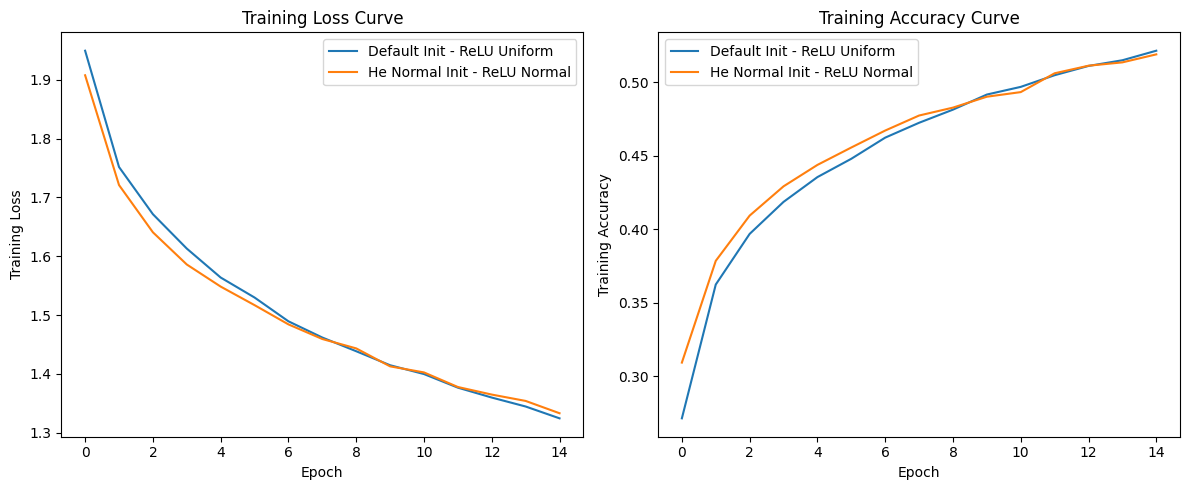

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(relu_train_losses, label='Default Init - ReLU Uniform')
plt.plot(he_train_losses, label='He Normal Init - ReLU Normal')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.legend()

# Plot training accuracy
plt.subplot(1, 2, 2)
plt.plot(relu_train_accuracies, label='Default Init - ReLU Uniform')
plt.plot(he_train_accuracies, label='He Normal Init - ReLU Normal')
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

# Default Init vs Xavier Init

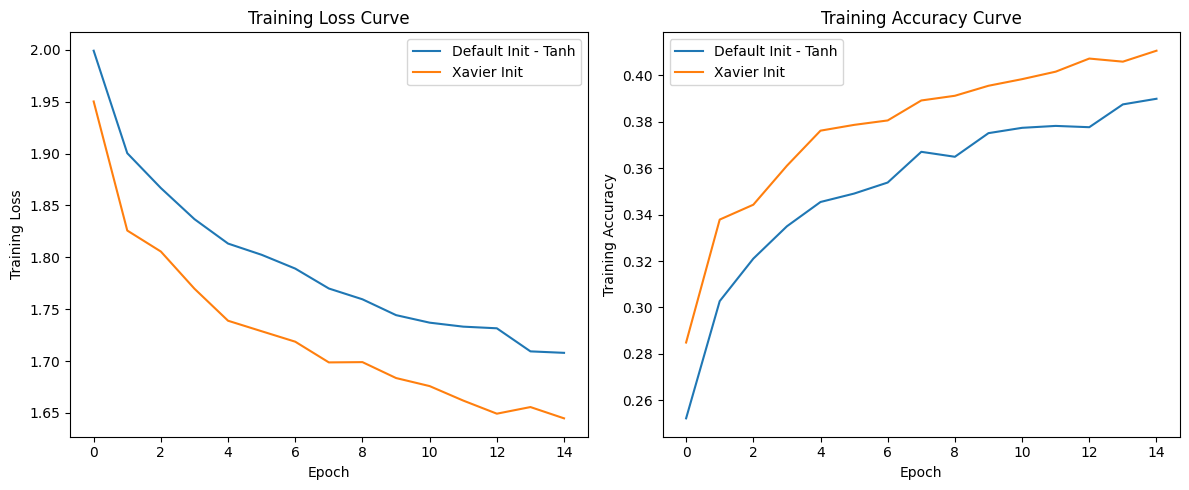

In [26]:
# Plot train loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(tanh_train_losses, label='Default Init - Tanh')
plt.plot(xavier_train_losses, label='Xavier Init')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.legend()

# Plot training accuracy
plt.subplot(1, 2, 2)
plt.plot(tanh_train_accuracies, label='Default Init - Tanh')
plt.plot(xavier_train_accuracies, label='Xavier Init')
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

We have now compared:

- **He Normal Init** vs. **Default Init (He Uniform)** for ReLU
- **Xavier Init** vs. **Default Init (He Uniform)** for Tanh

>**🧪 ReLU-Based Deep MLP**

| Observation | Insight |
|-------------|---------|
| 🔵 **Default Init - ReLU Uniform** and 🟠 **He Normal** show **very similar performance** in both training loss and accuracy. | This is expected — because PyTorch’s default for `nn.Linear` + ReLU is already **He Uniform**, which is well-suited for ReLU. |
| No clear gain from switching to **He Normal**. | While both preserve gradient flow, the difference between **uniform** and **normal** sampling is often minimal in practice. |

✅ **Conclusion**: For ReLU activations, PyTorch’s default initialization is already well-optimized. Explicit He Normal init shows similar outcomes.

>**🧪 Tanh-Based Deep MLP**

| Observation | Insight |
|-------------|---------|
| 🔵 **Default Init - Tanh** underperforms on both training loss and accuracy. | This is because the default He Uniform is **not suitable for Tanh**, which needs symmetric gradient handling. |
| 🟠 **Xavier Init** converges **faster** and achieves **better accuracy**. | Xavier was designed to preserve both forward and backward variance — making it ideal for symmetric activations like Tanh or Sigmoid. |

✅ **Conclusion**: For **Tanh (or Sigmoid)** activations, using **Xavier Initialization** gives clear improvements over the default.

In [27]:
CT_model_xavier = DeepMLP()
CT_model_he = DeepMLP()

# Apply Xavier to first model
initialize_weights(CT_model_xavier, method="xavier")

# Try "he_normal" or "he_uniform" based on the custom function
initialize_weights(CT_model_he, method="he_normal")

# Print confirmation
print("CT_Xavier initialization applied to model_xavier.")
print("CT_He initialization applied to model_he.")

CT_Xavier initialization applied to model_xavier.
CT_He initialization applied to model_he.
